In [3]:
import pandas as pd

data = pd.read_csv(r"C:\Users\keert\Downloads\supermarket-data\Sample - Superstore.csv", encoding='latin1')


In [4]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data.drop_duplicates(inplace=True)
data.dropna(inplace=True)


In [6]:
print(data.columns)


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


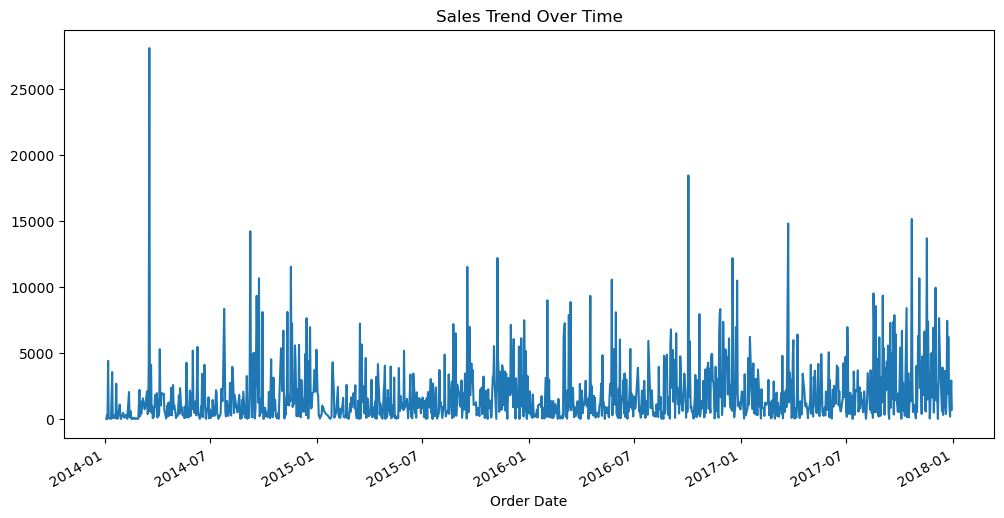

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales over time
data.groupby('Order Date')['Sales'].sum().plot(figsize=(12,6))
plt.title('Sales Trend Over Time')
plt.show()

C:\Users\keert\AppData\Local\Temp\ipykernel_31272\1695062924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


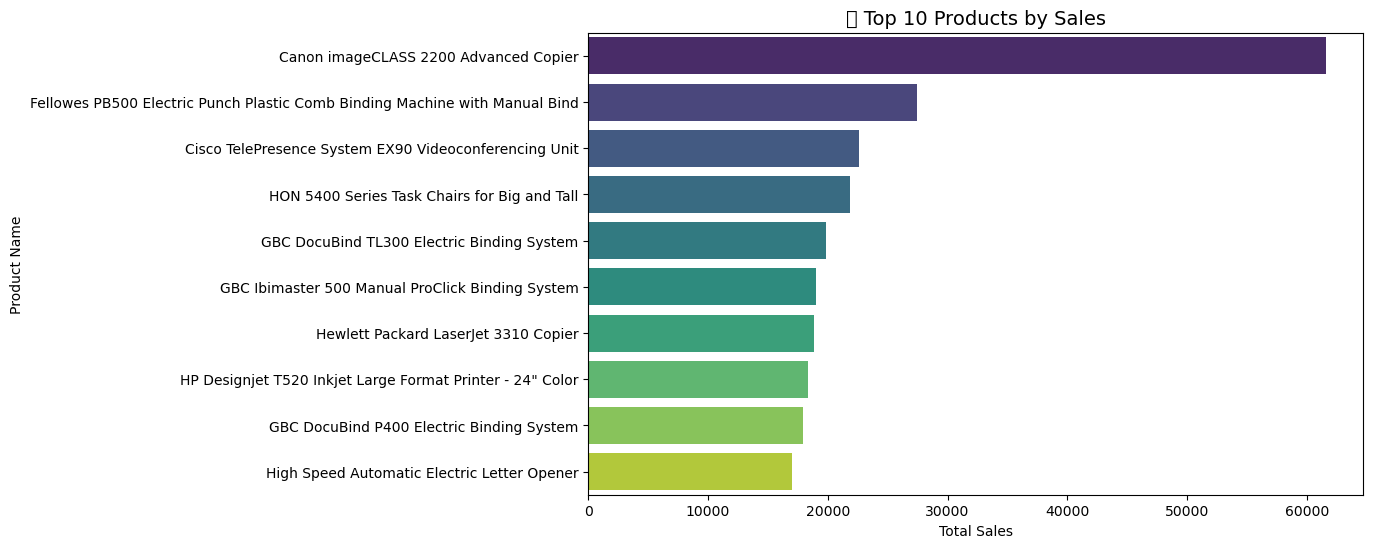

In [8]:
top_products = (
    data.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('🏆 Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.show()

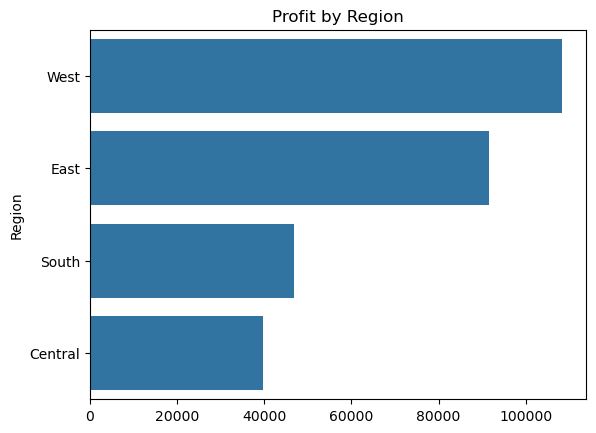

In [9]:
region_profit = data.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=region_profit.values, y=region_profit.index)
plt.title('Profit by Region')
plt.show()

C:\Users\keert\AppData\Local\Temp\ipykernel_31272\168586430.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.resample('M', on='Order Date')['Sales'].sum()
C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


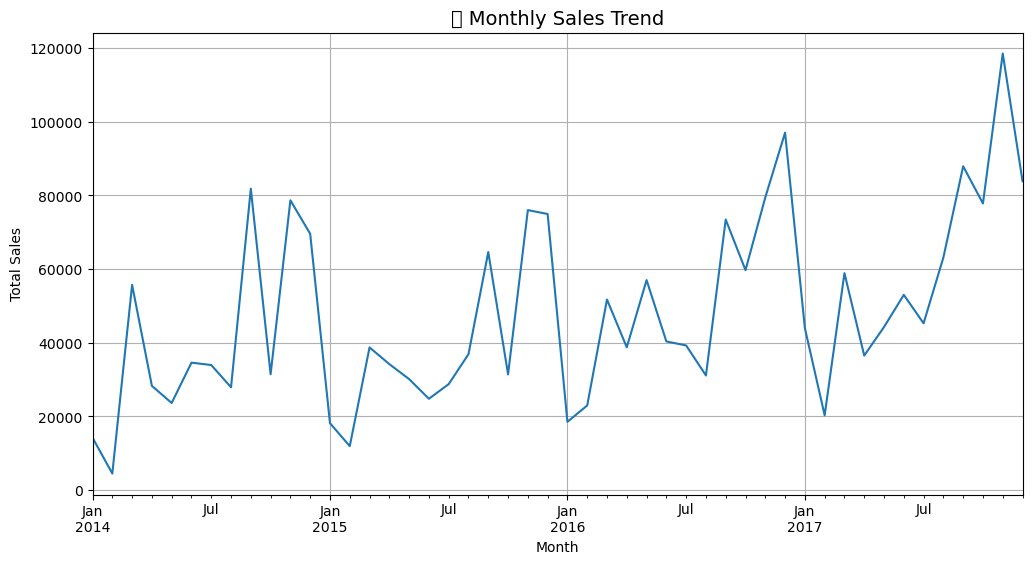

In [11]:
monthly_sales = data.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('🗓️ Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

<Figure size 800x500 with 0 Axes>

C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


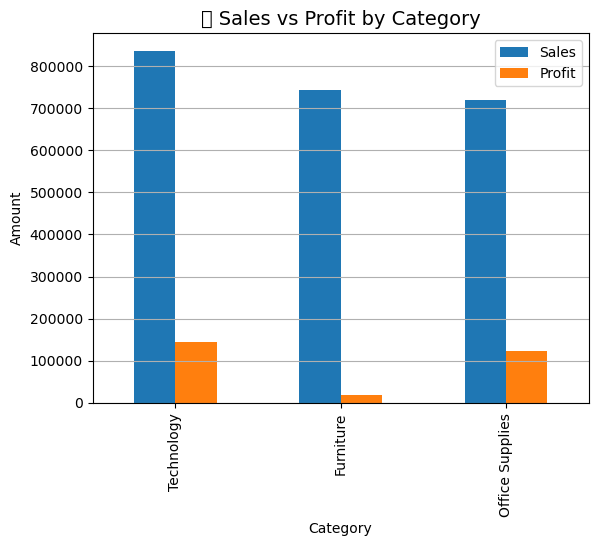

In [13]:
category_perf = (
    data.groupby('Category')[['Sales', 'Profit']]
    .sum()
    .sort_values(by='Sales', ascending=False)
)

plt.figure(figsize=(8,5))
category_perf.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('📊 Sales vs Profit by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Amount')
plt.grid(axis='y')
plt.show()

In [15]:
sales = data.groupby('Order Date')['Sales'].sum()


In [16]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

data['Order Date'] = pd.to_datetime(data['Order Date'])

sales = data.groupby('Order Date')['Sales'].sum().sort_index()

monthly_sales = sales.resample('M').sum()

C:\Users\keert\AppData\Local\Temp\ipykernel_31272\2791011530.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales.resample('M').sum()


In [17]:
model = ARIMA(monthly_sales, order=(1,1,1))
fit = model.fit()

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.895
Date:                Tue, 28 Oct 2025   AIC                           1085.789
Time:                        15:06:43   BIC                           1091.340
Sample:                    01-31-2014   HQIC                          1087.878
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2278      0.262      0.868      0.386      -0.287       0.742
ma.L1         -0.8396      0.140     -5.979      0.000      -1.115      -0.564
sigma2      5.976e+08   6.93e-11   8.63e+18      0.0

C:\Users\keert\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


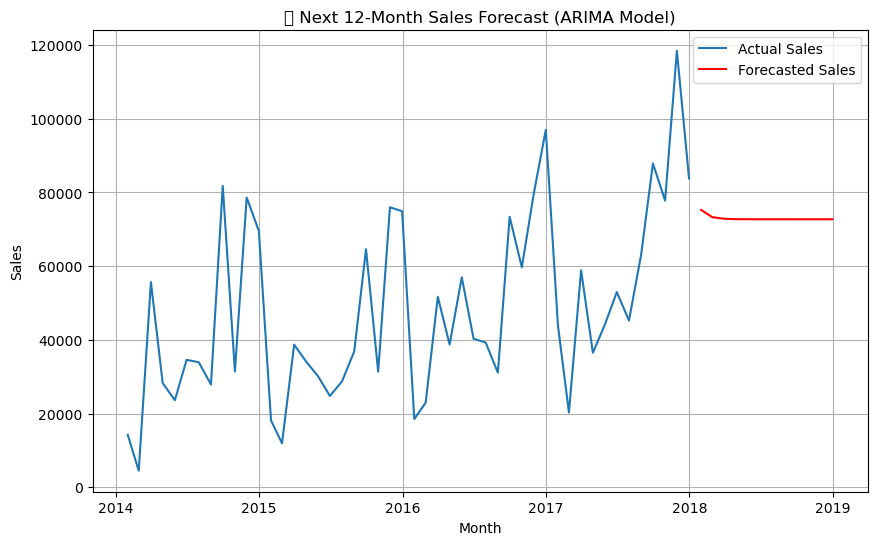

In [18]:
# Forecast next 12 months
forecast = fit.forecast(steps=12)

plt.figure(figsize=(10,6))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(forecast, label='Forecasted Sales', color='red')
plt.title("🧭 Next 12-Month Sales Forecast (ARIMA Model)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\keert\AppData\Local\Temp\ipykernel_31272\759825592.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_sales = sales.asfreq('D').fillna(method='ffill')  # fill missing dates


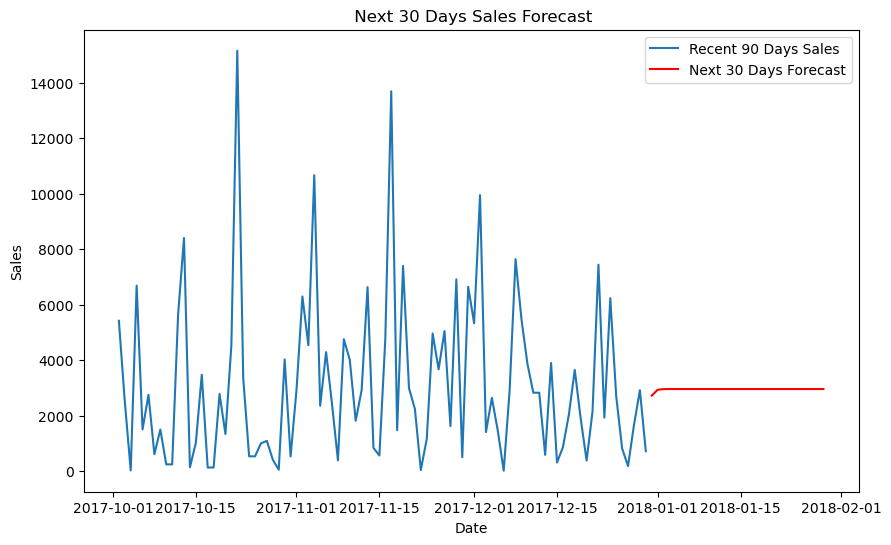

In [20]:
daily_sales = sales.asfreq('D').fillna(method='ffill')  # fill missing dates
model = ARIMA(daily_sales, order=(1,1,1))
fit = model.fit()
forecast = fit.forecast(steps=30)

plt.figure(figsize=(10,6))
plt.plot(daily_sales[-90:], label='Recent 90 Days Sales')
plt.plot(forecast, label='Next 30 Days Forecast', color='red')
plt.title(" Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train = monthly_sales[:-6]
test = monthly_sales[-6:]

model = ARIMA(train, order=(1,1,1))
fit = model.fit()
pred = fit.forecast(steps=6)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 31473.12, RMSE: 37548.42
